In [1]:
#importing cell

import CommunityModelClass3 as cmc3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output
import csv



## Niche Overlaps trends with fixed $l = 0.5$

Set inputs for the Simulations

In [2]:
inputs = {}

inputs["S_tot"]=80
inputs["S"] = 40
inputs["R"] = 40

# initial conditions
inputs["S0"] = 10
inputs["R0"] = 5

# time simulation params
inputs["time_period"] = 1e5
inputs["t_step"] = 0.1

# partitions params
inputs["num_F"] = 4
inputs["num_T"] = 4
inputs["partition_F"] = [20]*4
inputs["partition_T"] = [10]*4

# leakage
inputs["leakage"] = 0.5

# activation function
inputs["sigma_type"] = "linear"
inputs["k"] = 20                           
inputs["N"] = 2

# h function params
inputs["tau_R"] = 1
inputs["k_alpha_index"] = 0

# metabolic matrix params
inputs["f_c"] = 0.25
inputs["f_s"] = 0.25
inputs["d0"] = 0.2

# preference matrix params
inputs["preference_type"] = "binary"
inputs["c_0"] = 1
inputs["mu_c"] = 4.5
inputs["sigma_c"] = 0.3
inputs["q_A"] = 0.5

In [3]:
np.random.seed(42)

num_simulations = 10
num_c1s = 10

c1s = np.logspace(-1.6, 0, num=num_c1s, base=2) # log: (-1.6, 0) -> lin: (0.33, 1)
modelseed = np.random.randint(0, 1000, num_simulations)
print("c1s:\n",c1s,"\n")
print("modelseed:\n", modelseed)

c1s:
 [0.32987698 0.37313712 0.4220704  0.4774208  0.54002987 0.6108495
 0.69095644 0.78156862 0.8840637  1.        ] 

modelseed:
 [102 435 860 270 106  71 700  20 614 121]


### Restricted Regime


In [4]:
inputs["k_0"] = 10

survived_array_RR = np.zeros((num_simulations, num_c1s))
Niches_RR = []

for (i, c_1) in enumerate(c1s):
    inputs["c_1"] = c_1
    model=cmc3.CommunityModel(inputs)
    for j in range(num_simulations):
        model.ModelSeed(modelseed[j])
        model.Simulate()
        clear_output(wait=True)
        end_species = model.ReturnData("species")[-1]
        end_species[end_species < 1] = 0
        index = np.nonzero(end_species)[0]
        richness = len(index)
        print(f'c1:{i}, simulation:{j}')
        print(richness)
        survived_array_RR[j,i] = richness
    n = model.ReturnNicheOverlap()
    Niches_RR.append(n)


c1:9, simulation:9
2


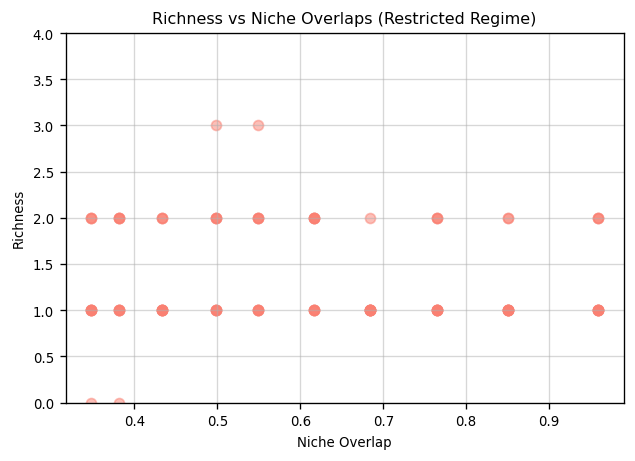

In [5]:
plt.figure(figsize=(6,4))
for j in range(num_simulations):
    plt.scatter(Niches_RR, survived_array_RR[j,:], c='salmon', alpha=0.5)
plt.title(f'Richness vs Niche Overlaps (Restricted Regime)')
plt.xlabel("Niche Overlap"), plt.ylabel("Richness")
plt.ylim(0, np.max(survived_array_RR) + 1)
plt.grid(alpha=0.5);

### Diverse Regime

In [6]:
inputs["k_0"] = 1000

survived_array_DR = np.zeros((num_simulations, num_c1s))
Niches_DR = []

for (i, c_1) in enumerate(c1s):
    inputs["c_1"] = c_1
    model=cmc3.CommunityModel(inputs)
    for j in range(num_simulations):
        model.ModelSeed(modelseed[j])
        model.Simulate()
        clear_output(wait=True)
        end_species = model.ReturnData("species")[-1]
        end_species[end_species < 1] = 0
        index = np.nonzero(end_species)[0]
        richness = len(index)
        print(f'c1:{i}, simulation:{j}')
        print(richness)
        survived_array_DR[j,i] = richness
    n = model.ReturnNicheOverlap()
    Niches_DR.append(n)


c1:9, simulation:9
3


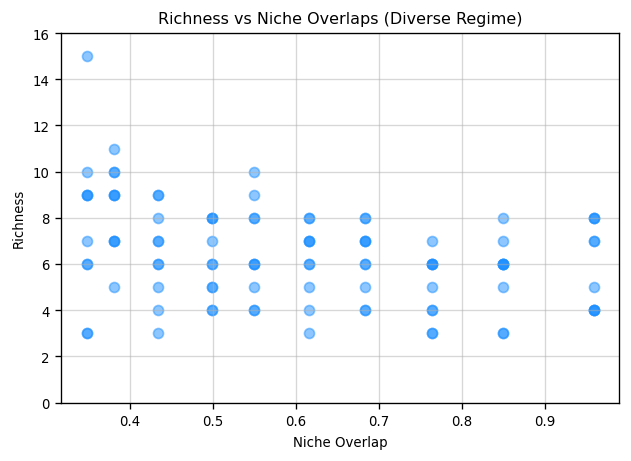

In [7]:
plt.figure(figsize=(6,4))
for j in range(num_simulations):
    plt.scatter(Niches_DR, survived_array_DR[j,:], c='dodgerblue', alpha=0.5)
plt.title(f'Richness vs Niche Overlaps (Diverse Regime)')
plt.xlabel("Niche Overlap"), plt.ylabel("Richness")
plt.ylim(0, np.max(survived_array_DR) + 1)
plt.grid(alpha=0.5);

### Comparison Restricted Regime and Diverse Regime

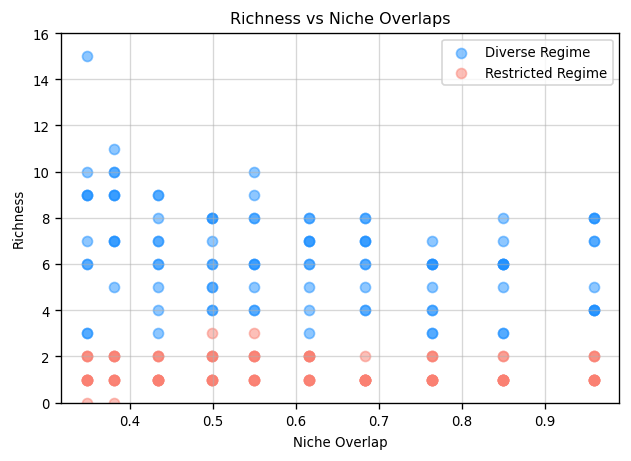

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(Niches_DR*num_simulations, survived_array_DR.flatten(), c='dodgerblue', alpha=0.5, label='Diverse Regime') # diverse regime
plt.scatter(Niches_RR*num_simulations, survived_array_RR.flatten(), c='salmon', alpha=0.5, label='Restricted Regime') # restricted regime
plt.title(f'Richness vs Niche Overlaps')
plt.xlabel('Niche Overlap'), plt.ylabel('Richness')
plt.ylim(0, np.max(survived_array_DR) + 1)
plt.legend()
plt.grid(alpha=0.5);

In [9]:
def lin_func(x, m, q):
    return q + m * x

In [10]:
Y_RR = survived_array_RR.flatten()
X_RR = Niches_RR * num_simulations
popt_RR, pcov_RR = curve_fit(lin_func, X_RR, Y_RR)
print(f'optimal parameters RR fit: {popt_RR}')

optimal parameters RR fit: [-0.1651259  1.4404337]


In [11]:
Y_DR = survived_array_DR.flatten()
X_DR = Niches_DR * num_simulations
popt_DR, pcov_DR = curve_fit(lin_func, X_DR, Y_DR)
print(f'optimal parameters DR fit: {popt_DR}')

optimal parameters DR fit: [-3.64913558  8.61949529]


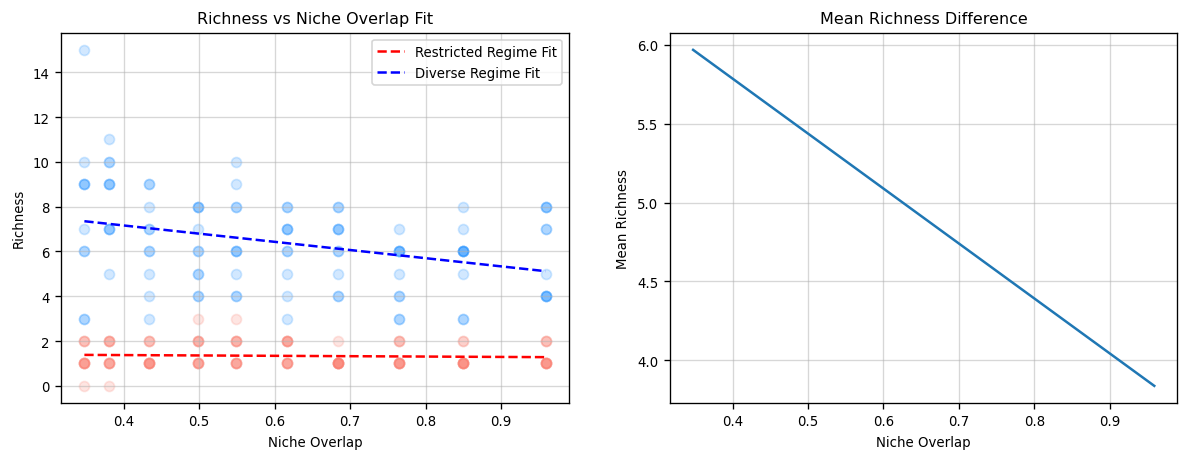

In [12]:
x_RR = np.linspace(np.min(Niches_RR), np.max(Niches_RR), num=100)
y_RR = lin_func(x_RR, popt_RR[0], popt_RR[1])
x_DR = np.linspace(np.min(Niches_DR), np.max(Niches_DR), num=100)
y_DR = lin_func(x_DR, popt_DR[0], popt_DR[1])
distance = y_DR-y_RR

fig, ax = plt.subplots(1,2,figsize=(12,4))
# Plot real data
ax[0].set(title='Richness vs Niche Overlap Fit',xlabel='Niche Overlap',ylabel='Richness')
ax[0].scatter(Niches_RR*num_simulations, survived_array_RR.flatten(), c='salmon', alpha=0.2)
ax[0].scatter(Niches_DR*num_simulations, survived_array_DR.flatten(), c='dodgerblue', alpha=0.2)
# Plot fit
ax[0].plot(x_RR, y_RR, 'r--', label='Restricted Regime Fit')
ax[0].plot(x_DR, y_DR, 'b--', label='Diverse Regime Fit')
ax[0].legend()
ax[0].grid(alpha=0.5)

ax[1].set(title='Mean Richness Difference',xlabel='Niche Overlap',ylabel='Mean Richness')
ax[1].plot(x_DR,distance)
ax[1].grid(alpha=0.5)
